In [1]:

import pandas as pd
import numpy as np

train_df = pd.read_csv('emnist-balanced-train.csv', header=None)
test_df  = pd.read_csv('emnist-balanced-test.csv',  header=None)

# First column is the label, rest are 784 pixel values
y_train = train_df.iloc[:, 0].values
X_train = train_df.iloc[:, 1:].values

y_test  = test_df.iloc[:, 0].values
X_test  = test_df.iloc[:, 1:].values

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {len(np.unique(y_train))}")

"""This data set consists of balanced classes of handwritten characters, including digits and letters. Each image is 28x28 pixels, flattened into a 784-dimensional vector. The labels correspond to the character class, with 47 unique classes in total."""

Train: (112800, 784), Test: (18800, 784)
Classes: 47


'This data set consists of balanced classes of handwritten characters, including digits and letters. Each image is 28x28 pixels, flattened into a 784-dimensional vector. The labels correspond to the character class, with 47 unique classes in total.'

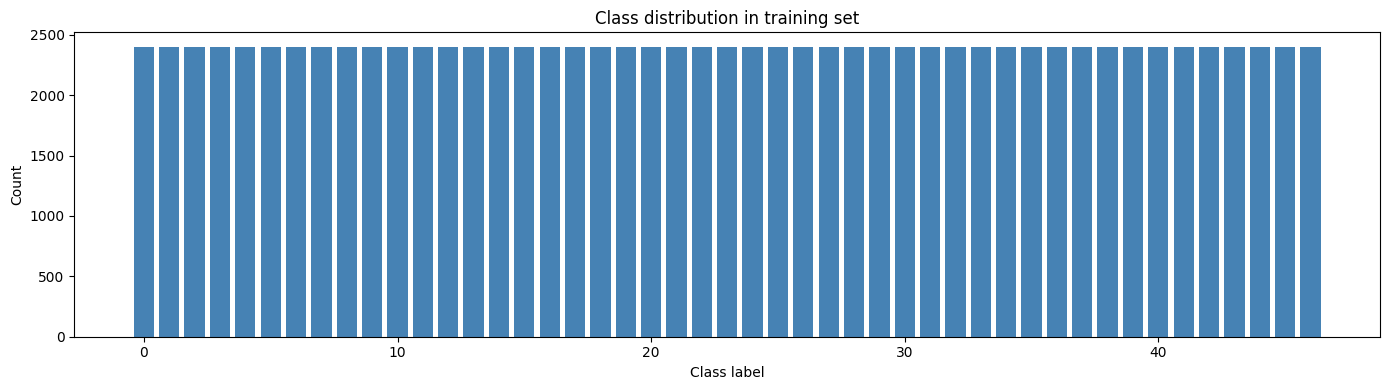

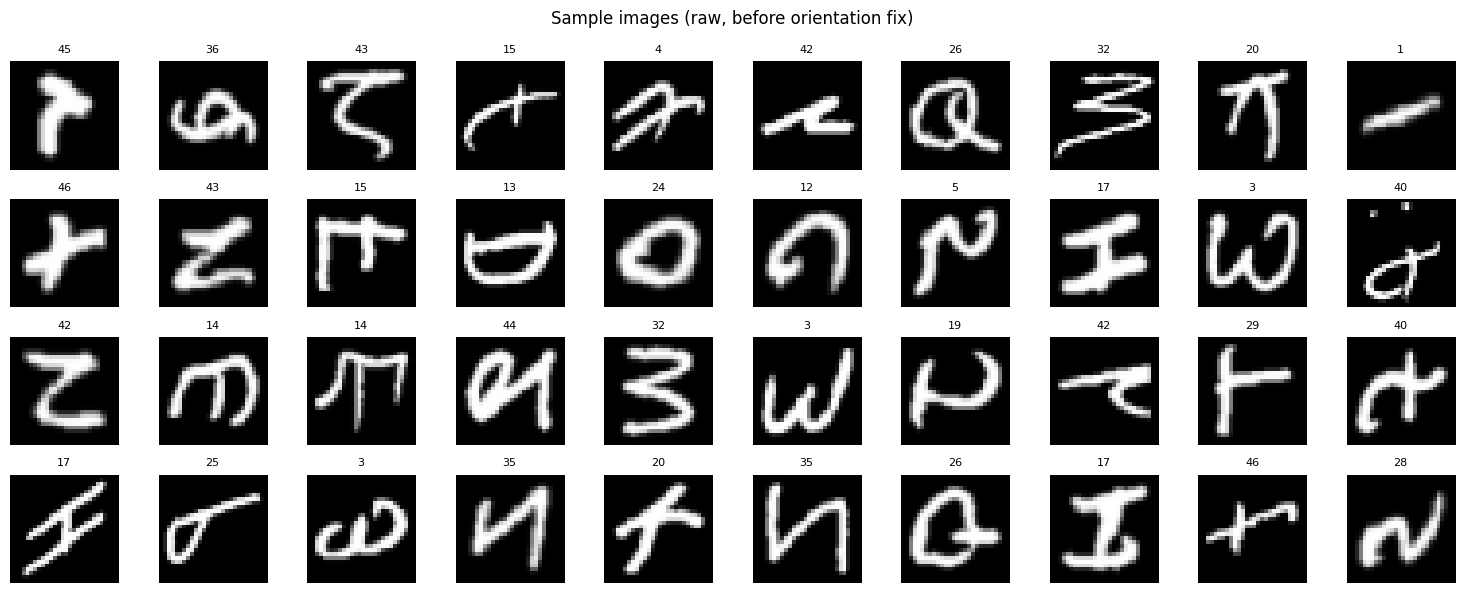

In [2]:
"""Visualizing sample images from the data set."""

import matplotlib.pyplot as plt

# Check class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(14, 4))
plt.bar(unique, counts, color='steelblue')
plt.title('Class distribution in training set')
plt.xlabel('Class label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Show sample images (raw, before any fix)
fig, axes = plt.subplots(4, 10, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(y_train[i]), fontsize=8)
    ax.axis('off')
plt.suptitle('Sample images (raw, before orientation fix)', fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
"""Performing load label mapping to convert numeric labels to their corresponding characters for better visualization."""

mapping = {}
with open('emnist-balanced-mapping.txt') as f:
    for line in f:
        idx, code = line.strip().split()
        mapping[int(idx)] = chr(int(code))

print("Total classes:", len(mapping))
print("Label map:", mapping)

Total classes: 47
Label map: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z', 36: 'a', 37: 'b', 38: 'd', 39: 'e', 40: 'f', 41: 'g', 42: 'h', 43: 'n', 44: 'q', 45: 'r', 46: 't'}


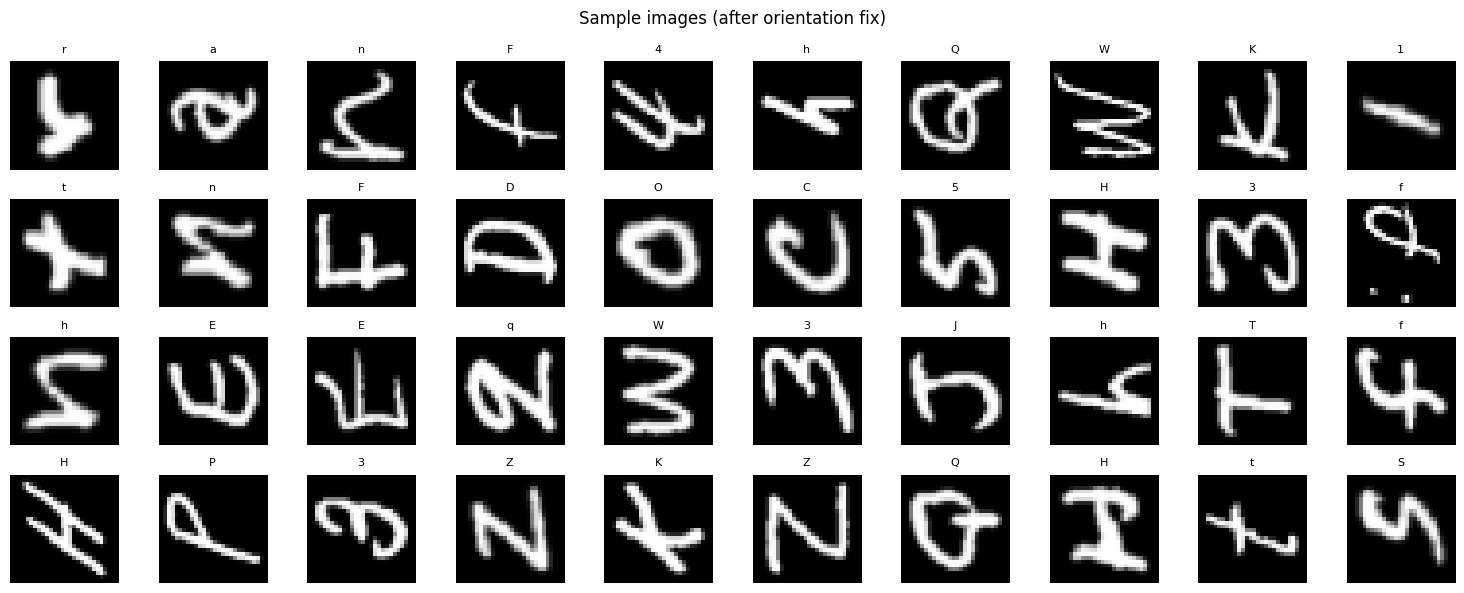

In [12]:
"""Fixing EMNIST Orientation:- The EMNIST dataset images are rotated and flipped. To correct this, we will rotate the images 90 degrees clockwise and then flip them horizontally. This will ensure that the characters are oriented correctly for visualization and model training."""

def fix_orientation(X):
    # Rotate 90 degrees clockwise
    X_rotated = np.array([np.rot90(img.reshape(28, 28), k=-1) for img in X])
    # Flip horizontally
    X_fixed = np.array([np.fliplr(img) for img in X_rotated])
    return X_fixed

X_train_fixed = fix_orientation(X_train)
X_test_fixed  = fix_orientation(X_test)

# Show sample images after orientation fix
fig, axes = plt.subplots(4, 10, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_fixed[i].reshape(28, 28), cmap='gray')
    ax.set_title(mapping[y_train[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample images (after orientation fix)', fontsize=12)
plt.tight_layout()
plt.show()




In [16]:
"""Here we will normalize, reshape, and one-hot encode our data. """

from tensorflow.keras.utils import to_categorical

X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encode labels
num_classes = len(mapping)  # 47
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_train_cat   : {y_train_cat.shape}")
print(f"num_classes   : {num_classes}")

X_train shape : (112800, 28, 28, 1)
X_test shape  : (18800, 28, 28, 1)
y_train_cat   : (112800, 47)
num_classes   : 47


In [17]:
"""Training and validation split for model evaluation."""

from sklearn.model_selection import train_test_split

X_train, X_val, y_train_cat, y_val_cat = train_test_split(
    X_train, y_train_cat,
    test_size=0.1,
    random_state=42,
    stratify=y_train       
)

print(f"Training samples   : {X_train.shape[0]}")
print(f"Validation samples : {X_val.shape[0]}")
print(f"Test samples       : {X_test.shape[0]}")


Training samples   : 101520
Validation samples : 11280
Test samples       : 18800


In [18]:
"""Data Augmentation - To improve model generalization, we will apply data augmentation techniques such as random rotations, shifts, and zooms to the training images. This will help the model learn to recognize characters in various orientations and scales."""


from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,       # rotate up to 10 degrees
    zoom_range=0.10,         # zoom in/out up to 10%
    width_shift_range=0.10,  # shift left/right up to 10%
    height_shift_range=0.10, # shift up/down up to 10%
    shear_range=0.10,        # shear transformation
    fill_mode='nearest'      # fill empty pixels with nearest value
)

datagen.fit(X_train)
print("Augmentation generator ready.")

Augmentation generator ready.


In [22]:
num_classes = len(mapping)
print(f"Number of classes: {num_classes}")  

Number of classes: 47


In [23]:
"""Building a CNN model """

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Flatten, Dense
)

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Classifier head
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')   # 47 output classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 47)             │        24,111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 756,239 (2.88 MB)

 Trainable params: 754,767 (2.88 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [24]:
"""Setting up callbacks for early stopping and model checkpointing to save the best model during training."""

from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
import os

os.makedirs('model', exist_ok=True)

callbacks = [
    ModelCheckpoint(
        'model/best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks ready.")

Callbacks ready.


In [34]:
"""training the model ."""

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=128),
    validation_data=(X_val, y_val_cat),
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

print("Training complete.")

Epoch 1/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.4858 - loss: 1.9667
Epoch 1: val_accuracy improved from None to 0.85824, saving model to model/best_model.h5



Epoch 1: finished saving model to model/best_model.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 88s 107ms/step - accuracy: 0.6493 - loss: 1.1916 - val_accuracy: 0.8582 - val_loss: 0.4083 - learning_rate: 0.0010
Epoch 2/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7931 - loss: 0.6027
Epoch 2: val_accuracy improved from 0.85824 to 0.87004, saving model to model/best_model.h5



Epoch 2: finished saving model to model/best_model.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 89s 111ms/step - accuracy: 0.8063 - loss: 0.5680 - val_accuracy: 0.8700 - val_loss: 0.3629 - learning_rate: 0.0010
Epoch 3/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.8281 - loss: 0.4966
Epoch 3: val_accuracy improved from 0.87004 to 0.87757, saving model to model/best_model.h5



Epoch 3: finished saving model to model/best_model.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 206s 260ms/step - accuracy: 0.8313 - loss: 0.4866 - val_accuracy: 0.8776 - val_loss: 0.3536 - learning_rate: 0.0010
Epoch 4/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8397 - loss: 0.4566
Epoch 4: val_accuracy did not improve from 0.87757
794/794 ━━━━━━━━━━━━━━━━━━━━ 90s 113ms/step - accuracy: 0.8417 - loss: 0.4506 - val_accuracy: 0.8746 - val_loss: 0.3344 - learning_rate: 0.0010
Epoch 5/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8455 - loss: 0.4366
Epoch 5: val_accuracy improved from 0.87757 to 0.88404, saving model to model/best_model.h5



Epoch 5: finished saving model to model/best_model.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 93s 117ms/step - accuracy: 0.8477 - loss: 0.4312 - val_accuracy: 0.8840 - val_loss: 0.3152 - learning_rate: 0.0010
Epoch 6/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8534 - loss: 0.4079
Epoch 6: val_accuracy improved from 0.88404 to 0.88431, saving model to model/best_model.h5


...


Epoch 17: finished saving model to model/best_model.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 96s 120ms/step - accuracy: 0.8835 - loss: 0.3121 - val_accuracy: 0.8984 - val_loss: 0.2721 - learning_rate: 5.0000e-04
Epoch 18/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8868 - loss: 0.3011
Epoch 18: val_accuracy did not improve from 0.89840
794/794 ━━━━━━━━━━━━━━━━━━━━ 91s 115ms/step - accuracy: 0.8862 - loss: 0.3054 - val_accuracy: 0.8976 - val_loss: 0.2669 - learning_rate: 5.0000e-04
Epoch 19/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8868 - loss: 0.2981
Epoch 19: val_accuracy improved from 0.89840 to 0.90027, saving model to model/best_model.h5



Epoch 19: finished saving model to model/best_model.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 90s 114ms/step - accuracy: 0.8869 - loss: 0.3015 - val_accuracy: 0.9003 - val_loss: 0.2695 - learning_rate: 5.0000e-04
Epoch 20/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8869 - loss: 0.3003
Epoch 20: val_accuracy did not improve from 0.90027
794/794 ━━━━━━━━━━━━━━━━━━━━ 93s 118ms/step - accuracy: 0.8875 - loss: 0.2997 - val_accuracy: 0.8976 - val_loss: 0.2770 - learning_rate: 5.0000e-04
Epoch 21/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8875 - loss: 0.3025
Epoch 21: val_accuracy improved from 0.90027 to 0.90124, saving model to model/best_model.h5



Epoch 21: finished saving model to model/best_model.h5

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
794/794 ━━━━━━━━━━━━━━━━━━━━ 93s 117ms/step - accuracy: 0.8878 - loss: 0.3002 - val_accuracy: 0.9012 - val_loss: 0.2668 - learning_rate: 5.0000e-04
Epoch 22/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8908 - loss: 0.2860
Epoch 22: val_accuracy improved from 0.90124 to 0.90195, saving model to model/best_model.h5



Epoch 22: finished saving model to model/best_model.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 93s 117ms/step - accuracy: 0.8906 - loss: 0.2873 - val_accuracy: 0.9020 - val_loss: 0.2625 - learning_rate: 2.5000e-04
Epoch 23/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8931 - loss: 0.2808
Epoch 23: val_accuracy did not improve from 0.90195
794/794 ━━━━━━━━━━━━━━━━━━━━ 88s 111ms/step - accuracy: 0.8920 - loss: 0.2847 - val_accuracy: 0.9004 - val_loss: 0.2636 - learning_rate: 2.5000e-04
Epoch 24/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8916 - loss: 0.2800
Epoch 24: val_accuracy did not improve from 0.90195
794/794 ━━━━━━━━━━━━━━━━━━━━ 84s 106ms/step - accuracy: 0.8924 - loss: 0.2824 - val_accuracy: 0.8996 - val_loss: 0.2650 - learning_rate: 2.5000e-04
Epoch 25/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8912 - loss: 0.2889
Epoch 25: val_accuracy did not improve from 0.90195

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


Epoch 26: finished saving model to model/best_model.h5
794/794 ━━━━━━━━━━━━━━━━━━━━ 84s 106ms/step - accuracy: 0.8951 - loss: 0.2774 - val_accuracy: 0.9023 - val_loss: 0.2585 - learning_rate: 1.2500e-04
Epoch 27/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8951 - loss: 0.2767
Epoch 27: val_accuracy did not improve from 0.90230
794/794 ━━━━━━━━━━━━━━━━━━━━ 85s 106ms/step - accuracy: 0.8950 - loss: 0.2760 - val_accuracy: 0.9015 - val_loss: 0.2581 - learning_rate: 1.2500e-04
Epoch 28/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.8972 - loss: 0.2710
Epoch 28: val_accuracy did not improve from 0.90230
794/794 ━━━━━━━━━━━━━━━━━━━━ 88s 111ms/step - accuracy: 0.8959 - loss: 0.2743 - val_accuracy: 0.9010 - val_loss: 0.2596 - learning_rate: 1.2500e-04
Epoch 29/50
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.8961 - loss: 0.2737
Epoch 29: val_accuracy did not improve from 0.90230
794/794 ━━━━━━━━━━━━━━━━━━━━ 87s 110ms/step - accuracy: 0.8964 - loss: 0.2724

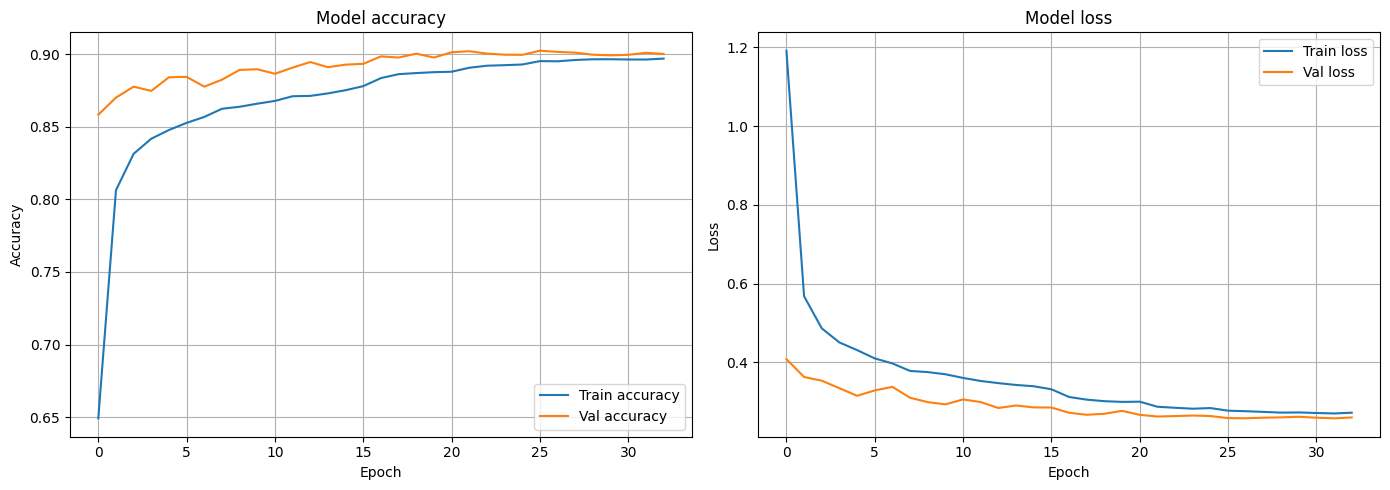

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train accuracy')
ax1.plot(history.history['val_accuracy'], label='Val accuracy')
ax1.set_title('Model accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'],     label='Train loss')
ax2.plot(history.history['val_loss'], label='Val loss')
ax2.set_title('Model loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best saved model for evaluation
from tensorflow.keras.models import load_model
best_model = load_model('model/best_model.h5')

test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy : {test_acc * 100:.2f}%")
print(f"Test loss     : {test_loss:.4f}")

# Per-class report
y_pred = best_model.predict(X_test).argmax(axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=[mapping[i] for i in range(num_classes)]))

Test accuracy : 90.28%
Test loss     : 0.2689
588/588 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.77      0.71       400
           1       0.51      0.71      0.59       400
           2       0.94      0.90      0.92       400
           3       1.00      0.99      0.99       400
           4       0.96      0.96      0.96       400
           5       0.96      0.92      0.94       400
           6       0.97      0.95      0.96       400
           7       0.98      0.99      0.99       400
           8       0.98      0.98      0.98       400
           9       0.69      0.85      0.77       400
           A       0.98      0.99      0.98       400
           B       0.97      0.99      0.98       400
           C       0.98      0.97      0.97       400
           D       0.95      0.95      0.95       400
           E       0.98      0.99      0.99       400
           F       0.73 

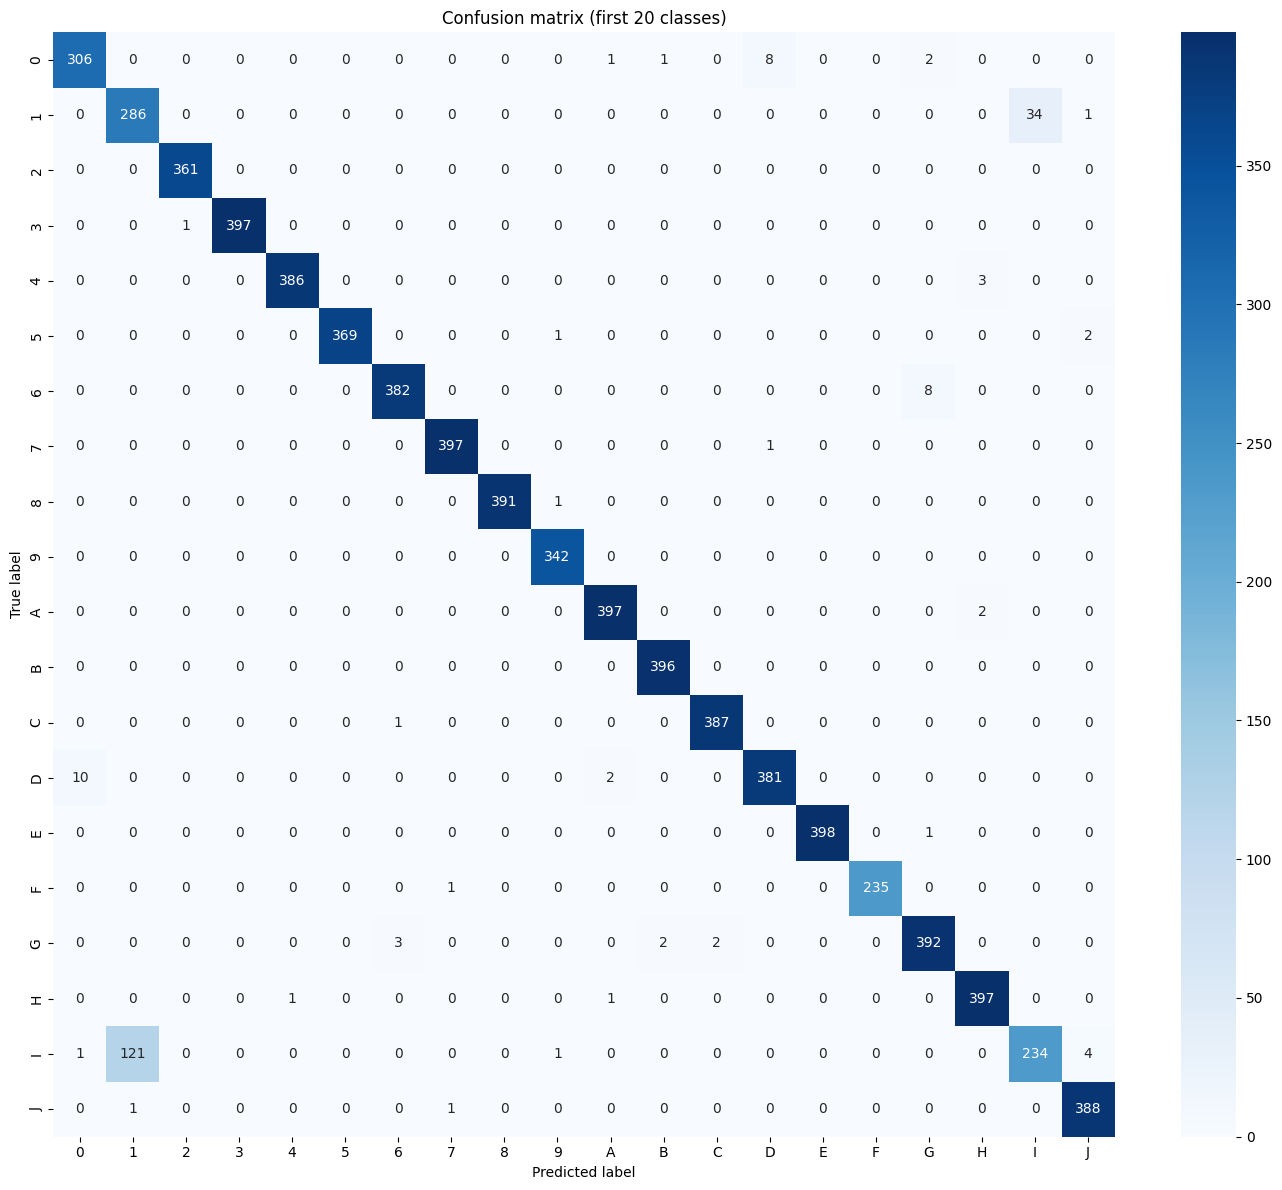

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm[:20, :20], annot=True, fmt='d', cmap='Blues',
            xticklabels=[mapping[i] for i in range(20)],
            yticklabels=[mapping[i] for i in range(20)])
plt.title('Confusion matrix (first 20 classes)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

In [ ]:
wrong_idx = np.where(y_pred != y_test)[0][:25]

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
for ax, idx in zip(axes.flat, wrong_idx):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(
        f"T: {mapping[y_test[idx]]}  P: {mapping[y_pred[idx]]}",
        fontsize=9, color='red'
    )
    ax.axis('off')
plt.suptitle('Misclassified samples (True → Predicted)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
import json

label_map = {str(k): v for k, v in mapping.items()}

with open('model/class_labels.json', 'w') as f:
    json.dump(label_map, f, indent=2)

print("Saved class_labels.json")
print(label_map)

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 47)             │        24,111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,775 (8.64 MB)

 Trainable params: 754,767 (2.88 MB)

 Non-trainable params: 1,472 (5.75 KB)

 Optimizer params: 1,509,536 (5.76 MB)